# P19 — Auto-Encoding Variational Bayes (VAE)
## UFCEKN-30-3 Advanced Machine Learning — Final Project

**Paper:** Kingma, D.P. and Welling, M. (2014) 'Auto-Encoding Variational Bayes', *ICLR 2014*.

**Part C Route:** Route 2 — Method Improvement (KL Annealing to address posterior collapse)

**GitHub:** [Insert your GitHub link here]

---

## 1. Setup & Dependencies
This notebook is designed to run on Google Colab with a free T4 GPU.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import os
import json
from collections import defaultdict

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


## 2. Data Loading

I use the MNIST dataset to reproduce the original paper's results. The paper uses
binarised MNIST with 60,000 training and 10,000 test images of 28×28 grayscale digits.
Following Kingma & Welling (2014), I treat pixel values as Bernoulli probabilities.

In [2]:
# Hyperparameters matching the paper where possible
BATCH_SIZE = 100       # M = 100 as stated in Algorithm 1 of the paper
LEARNING_RATE = 1e-3
EPOCHS = 50
LATENT_DIM = 20        # Nz — we test multiple values later
HIDDEN_DIM = 500       # 500 hidden units for MNIST (Section 5 of the paper)
INPUT_DIM = 784        # 28 * 28 = 784 flattened pixels
L_SAMPLES = 1          # L = 1 sample per datapoint (Section 5)

print(f'Configuration:')
print(f'  Batch size (M): {BATCH_SIZE}')
print(f'  Latent dim (Nz): {LATENT_DIM}')
print(f'  Hidden dim: {HIDDEN_DIM}')
print(f'  Learning rate: {LEARNING_RATE}')
print(f'  Epochs: {EPOCHS}')

Configuration:
  Batch size (M): 100
  Latent dim (Nz): 20
  Hidden dim: 500
  Learning rate: 0.001
  Epochs: 50


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 491kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.57MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.1MB/s]


Training samples: 60000
Test samples: 10000
Image shape: torch.Size([1, 28, 28])


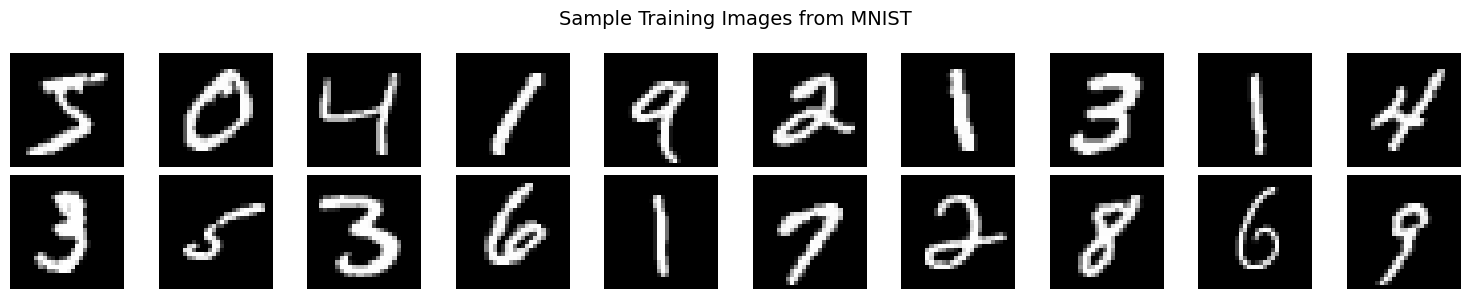

In [3]:
# Data loading — flatten images to 784-dim vectors as in the paper
transform = transforms.Compose([
    transforms.ToTensor(),  # Converts to [0, 1] range
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)

print(f'Training samples: {len(train_dataset)}')
print(f'Test samples: {len(test_dataset)}')
print(f'Image shape: {train_dataset[0][0].shape}')

# Visualise some training samples
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(20):
    ax = axes[i // 10, i % 10]
    ax.imshow(train_dataset[i][0].squeeze(), cmap='gray')
    ax.axis('off')
plt.suptitle('Sample Training Images from MNIST', fontsize=14)
plt.tight_layout()
plt.show()

## 3. VAE Model Architecture

The VAE consists of three components, following Section 3 and Appendix C of Kingma & Welling (2014):

**Encoder (Recognition model)** $q_\phi(z|x)$: Maps input $x$ to parameters of the approximate
posterior — mean $\mu$ and log-variance $\log \sigma^2$. Uses an MLP with one hidden layer (Appendix C.2).

**Reparameterization trick** (Section 2.4): Instead of sampling $z \sim \mathcal{N}(\mu, \sigma^2 I)$ directly
(which is not differentiable), we sample $\epsilon \sim \mathcal{N}(0, I)$ and compute
$z = \mu + \sigma \odot \epsilon$. This makes the sampling operation differentiable w.r.t. $\phi$.

**Decoder (Generative model)** $p_\theta(x|z)$: Maps latent code $z$ back to the data space.
For binary/Bernoulli data like MNIST, uses a sigmoid output (Appendix C.1, Equation 11).

In [4]:
class VAE(nn.Module):

    def __init__(self, input_dim=784, hidden_dim=500, latent_dim=20):
        super(VAE, self).__init__()

        self.latent_dim = latent_dim

        # --- Encoder (Recognition model) ---
        self.encoder_hidden = nn.Linear(input_dim, hidden_dim)
        self.encoder_mu = nn.Linear(hidden_dim, latent_dim)
        self.encoder_logvar = nn.Linear(hidden_dim, latent_dim)

        # --- Decoder (Generative model) ---
        self.decoder_hidden = nn.Linear(latent_dim, hidden_dim)
        self.decoder_output = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):

        # Single hidden layer with tanh activation (Appendix C.2)
        h = torch.tanh(self.encoder_hidden(x))
        mu = self.encoder_mu(h)
        log_var = self.encoder_logvar(h)
        return mu, log_var

    def reparameterize(self, mu, log_var):

        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        z = mu + std * eps
        return z

    def decode(self, z):

        h = torch.tanh(self.decoder_hidden(z))
        x_recon = torch.sigmoid(self.decoder_output(h))
        return x_recon

    def forward(self, x):

        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        x_recon = self.decode(z)
        return x_recon, mu, log_var, z


# Instantiate model and print architecture
model = VAE(INPUT_DIM, HIDDEN_DIM, LATENT_DIM).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters: {total_params:,}')

VAE(
  (encoder_hidden): Linear(in_features=784, out_features=500, bias=True)
  (encoder_mu): Linear(in_features=500, out_features=20, bias=True)
  (encoder_logvar): Linear(in_features=500, out_features=20, bias=True)
  (decoder_hidden): Linear(in_features=20, out_features=500, bias=True)
  (decoder_output): Linear(in_features=500, out_features=784, bias=True)
)

Total parameters: 815,824


## 4. Loss Function — Evidence Lower Bound (ELBO)

The VAE is trained by maximising the Evidence Lower Bound (ELBO), or equivalently
minimising the negative ELBO. From Equation 7 in the paper:

$$\mathcal{L}(\theta, \phi; x^{(i)}) = -D_{KL}(q_\phi(z|x^{(i)}) \| p_\theta(z)) + \mathbb{E}_{q_\phi(z|x^{(i)})}[\log p_\theta(x^{(i)}|z)]$$

**Term 1 — KL Divergence** (Appendix B): Acts as a regulariser, keeping the approximate
posterior close to the prior $\mathcal{N}(0, I)$. Has a closed-form solution (Equation 10):

$$-D_{KL} = \frac{1}{2} \sum_{j=1}^{J} \left(1 + \log(\sigma_j^2) - \mu_j^2 - \sigma_j^2\right)$$

**Term 2 — Reconstruction Loss**: The expected negative reconstruction error under the
approximate posterior. For Bernoulli decoder, this is binary cross-entropy (Eq. 11).

In [5]:
def vae_loss(x_recon, x, mu, log_var, kl_weight=1.0):

    # Reconstruction loss: Binary cross-entropy
    recon_loss = F.binary_cross_entropy(x_recon, x, reduction='sum') / x.size(0)

    # KL divergence: closed-form for Gaussian
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / x.size(0)

    # Total loss = reconstruction + weighted KL
    total_loss = recon_loss + kl_weight * kl_loss

    return total_loss, recon_loss, kl_loss

print('Loss function defined: negative ELBO = BCE reconstruction + KL divergence')

Loss function defined: negative ELBO = BCE reconstruction + KL divergence


## 5. Training Loop

Following Algorithm 1 in the paper: iterate over minibatches of size $M = 100$,
compute gradients of the ELBO estimator, and update parameters.
The paper uses Adagrad; I use Adam (a modern successor) with similar adaptive
learning rate properties.

In [6]:
def train_vae(model, train_loader, test_loader, epochs, lr=1e-3,
              kl_schedule='fixed', kl_weight_fixed=1.0,
              n_cycles=4, warmup_ratio=0.5, device='cpu'):

    optimizer = optim.Adam(model.parameters(), lr=lr)

    total_steps = epochs * len(train_loader)

    history = {
        'train_loss': [], 'train_recon': [], 'train_kl': [],
        'test_loss': [], 'test_recon': [], 'test_kl': [],
        'kl_weights': []
    }

    step = 0

    for epoch in range(epochs):
        # --- Training ---
        model.train()
        epoch_loss, epoch_recon, epoch_kl = 0.0, 0.0, 0.0
        epoch_kl_weight = 0.0

        for batch_idx, (data, _) in enumerate(train_loader):
            # Flatten images: (batch, 1, 28, 28) -> (batch, 784)
            data = data.view(-1, INPUT_DIM).to(device)

            # Compute KL weight based on schedule
            if kl_schedule == 'fixed':
                kl_weight = kl_weight_fixed
            elif kl_schedule == 'linear':
                # Linear warm-up: 0 -> 1 over all training steps
                kl_weight = min(1.0, step / (total_steps * 0.5))
            elif kl_schedule == 'cyclical':
                # Cyclical annealing
                cycle_length = total_steps / n_cycles
                cycle_pos = (step % cycle_length) / cycle_length
                if cycle_pos < warmup_ratio:
                    kl_weight = cycle_pos / warmup_ratio
                else:
                    kl_weight = 1.0

            # Forward pass
            x_recon, mu, log_var, z = model(data)
            loss, recon, kl = vae_loss(x_recon, data, mu, log_var, kl_weight)

            # Backward pass and optimise
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            epoch_recon += recon.item()
            epoch_kl += kl.item()
            epoch_kl_weight += kl_weight
            step += 1

        n_batches = len(train_loader)
        history['train_loss'].append(epoch_loss / n_batches)
        history['train_recon'].append(epoch_recon / n_batches)
        history['train_kl'].append(epoch_kl / n_batches)
        history['kl_weights'].append(epoch_kl_weight / n_batches)

        # --- Evaluation ---
        model.eval()
        test_loss, test_recon, test_kl = 0.0, 0.0, 0.0

        with torch.no_grad():
            for data, _ in test_loader:
                data = data.view(-1, INPUT_DIM).to(device)
                x_recon, mu, log_var, z = model(data)
                loss, recon, kl = vae_loss(x_recon, data, mu, log_var, kl_weight=1.0)
                test_loss += loss.item()
                test_recon += recon.item()
                test_kl += kl.item()

        n_test = len(test_loader)
        history['test_loss'].append(test_loss / n_test)
        history['test_recon'].append(test_recon / n_test)
        history['test_kl'].append(test_kl / n_test)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f'Epoch {epoch+1:3d}/{epochs} | '
                  f'Train Loss: {history["train_loss"][-1]:.1f} '
                  f'(Recon: {history["train_recon"][-1]:.1f}, '
                  f'KL: {history["train_kl"][-1]:.1f}) | '
                  f'Test Loss: {history["test_loss"][-1]:.1f} | '
                  f'KL weight: {history["kl_weights"][-1]:.3f}')

    return history

## 6. Train Standard VAE (Baseline)

First, I train the standard VAE with fixed KL weight = 1.0 as described in the
original paper (Section 5). This serves as the baseline for Part C comparison.

In [7]:
# Train standard VAE (fixed KL weight = 1.0)
print('='*70)
print('Training STANDARD VAE (fixed KL weight = 1.0)')
print('='*70)

model_standard = VAE(INPUT_DIM, HIDDEN_DIM, LATENT_DIM).to(device)
history_standard = train_vae(
    model_standard, train_loader, test_loader,
    epochs=EPOCHS, lr=LEARNING_RATE,
    kl_schedule='fixed', kl_weight_fixed=1.0,
    device=device
)

Training STANDARD VAE (fixed KL weight = 1.0)
Epoch   1/50 | Train Loss: 152.3 (Recon: 130.3, KL: 21.9) | Test Loss: 125.9 | KL weight: 1.000
Epoch  10/50 | Train Loss: 106.7 (Recon: 81.1, KL: 25.6) | Test Loss: 106.1 | KL weight: 1.000
Epoch  20/50 | Train Loss: 103.7 (Recon: 78.0, KL: 25.6) | Test Loss: 103.2 | KL weight: 1.000
Epoch  30/50 | Train Loss: 102.5 (Recon: 76.9, KL: 25.6) | Test Loss: 102.8 | KL weight: 1.000
Epoch  40/50 | Train Loss: 101.8 (Recon: 76.2, KL: 25.6) | Test Loss: 102.2 | KL weight: 1.000
Epoch  50/50 | Train Loss: 101.3 (Recon: 75.8, KL: 25.5) | Test Loss: 102.0 | KL weight: 1.000


## 7. Visualisation — Standard VAE Results

### 7.1 Training Curves
I plot the ELBO decomposition (total loss, reconstruction, and KL divergence)
to analyse training dynamics.

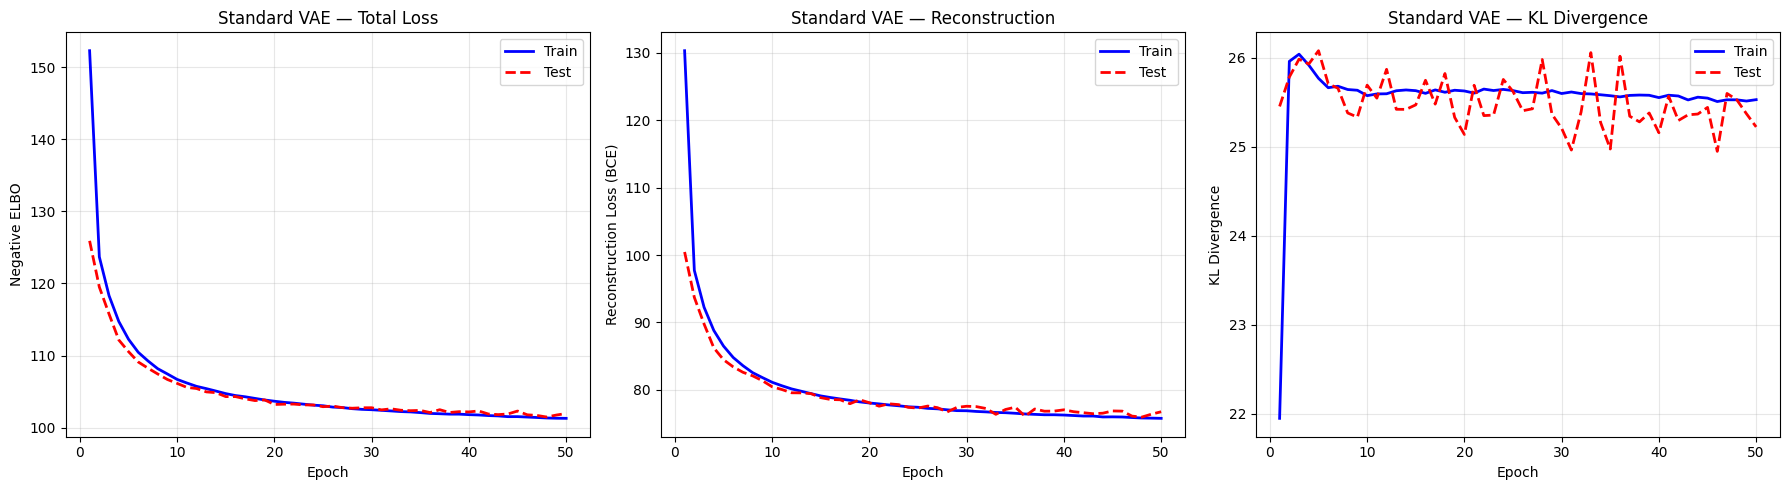

In [8]:
def plot_training_curves(history, title='Standard VAE'):
    """Plot training curves for total loss, reconstruction, and KL divergence."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    epochs_range = range(1, len(history['train_loss']) + 1)

    # Total loss (negative ELBO)
    axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Train', linewidth=2)
    axes[0].plot(epochs_range, history['test_loss'], 'r--', label='Test', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Negative ELBO')
    axes[0].set_title(f'{title} — Total Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Reconstruction loss
    axes[1].plot(epochs_range, history['train_recon'], 'b-', label='Train', linewidth=2)
    axes[1].plot(epochs_range, history['test_recon'], 'r--', label='Test', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Reconstruction Loss (BCE)')
    axes[1].set_title(f'{title} — Reconstruction')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # KL divergence
    axes[2].plot(epochs_range, history['train_kl'], 'b-', label='Train', linewidth=2)
    axes[2].plot(epochs_range, history['test_kl'], 'r--', label='Test', linewidth=2)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('KL Divergence')
    axes[2].set_title(f'{title} — KL Divergence')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_curves(history_standard, 'Standard VAE')

### 7.2 Reconstructions
Pass the test images through the encoder and decoder to check reconstruction quality.

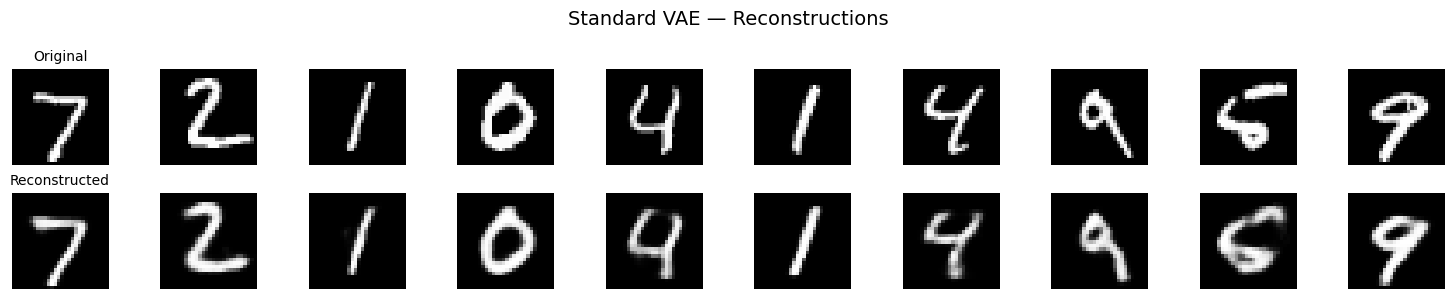

In [9]:
def plot_reconstructions(model, test_loader, n=10, title='Standard VAE'):
    """Show original images and their reconstructions side by side."""
    model.eval()
    data, _ = next(iter(test_loader))
    data = data.view(-1, INPUT_DIM).to(device)

    with torch.no_grad():
        x_recon, mu, log_var, z = model(data)

    fig, axes = plt.subplots(2, n, figsize=(15, 3))
    for i in range(n):
        # Original
        axes[0, i].imshow(data[i].cpu().view(28, 28), cmap='gray')
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title('Original', fontsize=10)

        # Reconstruction
        axes[1, i].imshow(x_recon[i].cpu().view(28, 28), cmap='gray')
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title('Reconstructed', fontsize=10)

    plt.suptitle(f'{title} — Reconstructions', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_reconstructions(model_standard, test_loader, title='Standard VAE')

### 7.3 Generated Samples
Sample $z \sim \mathcal{N}(0, I)$ from the prior and decode to generate new images,
as shown in Figure 5 of the paper.

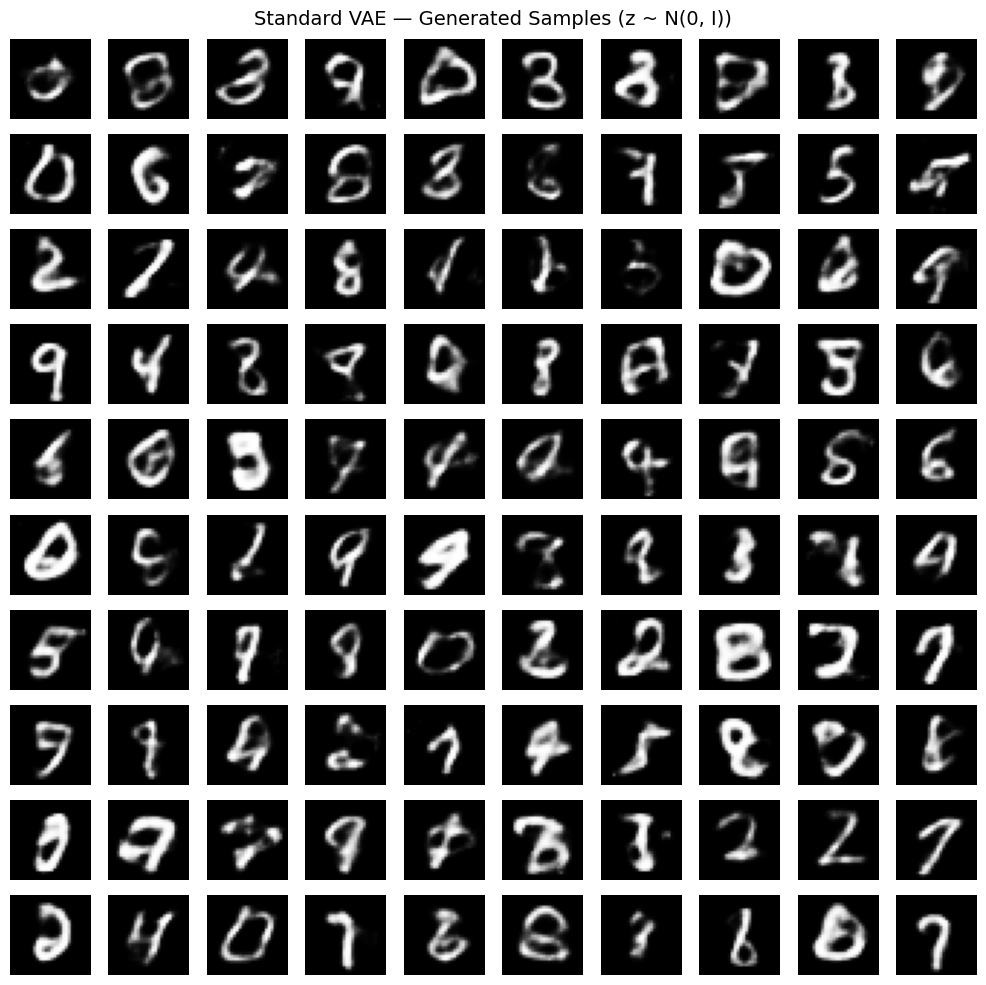

In [10]:
def plot_generated_samples(model, n=10, title='Standard VAE'):
    """Generate and plot new samples from the decoder."""
    model.eval()
    with torch.no_grad():
        z = torch.randn(n * n, model.latent_dim).to(device)
        samples = model.decode(z).cpu().view(-1, 28, 28)

    fig, axes = plt.subplots(n, n, figsize=(10, 10))
    for i in range(n):
        for j in range(n):
            axes[i, j].imshow(samples[i * n + j], cmap='gray')
            axes[i, j].axis('off')

    plt.suptitle(f'{title} — Generated Samples (z ~ N(0, I))', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_generated_samples(model_standard, n=10, title='Standard VAE')

### 7.4 Latent Space Visualisation
I encode test images into the latent space and visualise the 2D t-SNE projection
to inspect whether the latent space is structured.

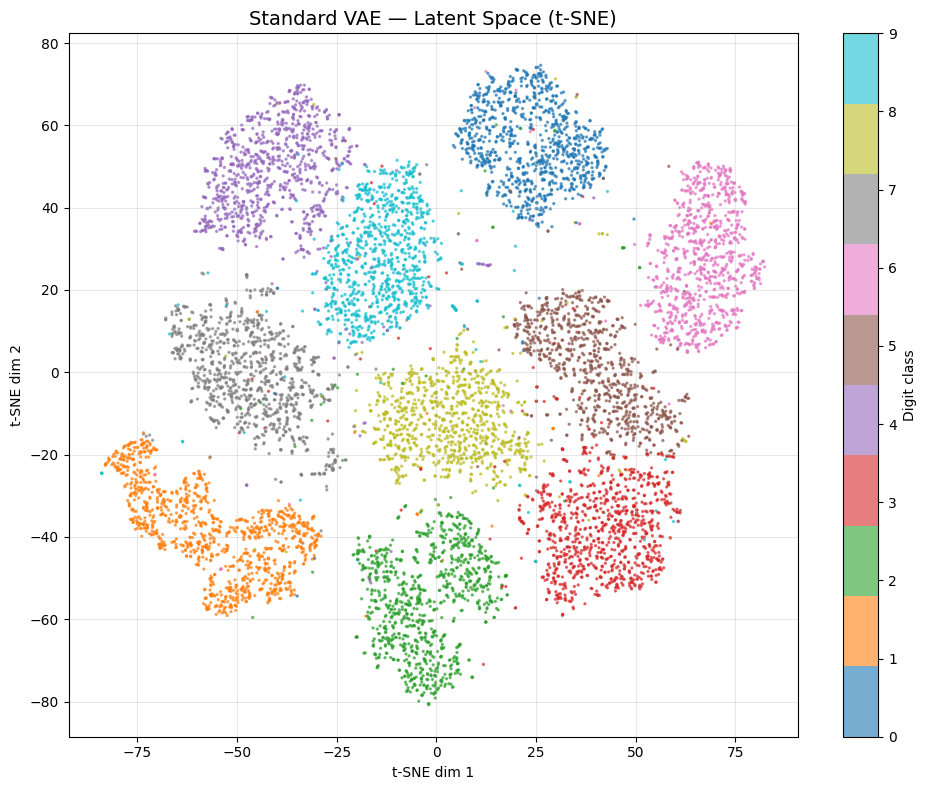

In [11]:
from sklearn.manifold import TSNE

def plot_latent_space(model, test_loader, title='Standard VAE'):
    """Visualise latent space using t-SNE, coloured by digit class."""
    model.eval()
    latents, labels = [], []

    with torch.no_grad():
        for data, target in test_loader:
            data = data.view(-1, INPUT_DIM).to(device)
            mu, log_var = model.encode(data)
            latents.append(mu.cpu().numpy())
            labels.append(target.numpy())

    latents = np.concatenate(latents, axis=0)
    labels = np.concatenate(labels, axis=0)

    # t-SNE reduction to 2D
    tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
    latents_2d = tsne.fit_transform(latents)

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(latents_2d[:, 0], latents_2d[:, 1],
                         c=labels, cmap='tab10', s=2, alpha=0.6)
    plt.colorbar(scatter, label='Digit class')
    plt.title(f'{title} — Latent Space (t-SNE)', fontsize=14)
    plt.xlabel('t-SNE dim 1')
    plt.ylabel('t-SNE dim 2')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_latent_space(model_standard, test_loader, title='Standard VAE')

### 7.5 Latent Space Traversal
I interpolate between two latent codes to visualise smooth transitions,
demonstrating that the learned latent space is continuous (a key property of VAEs).

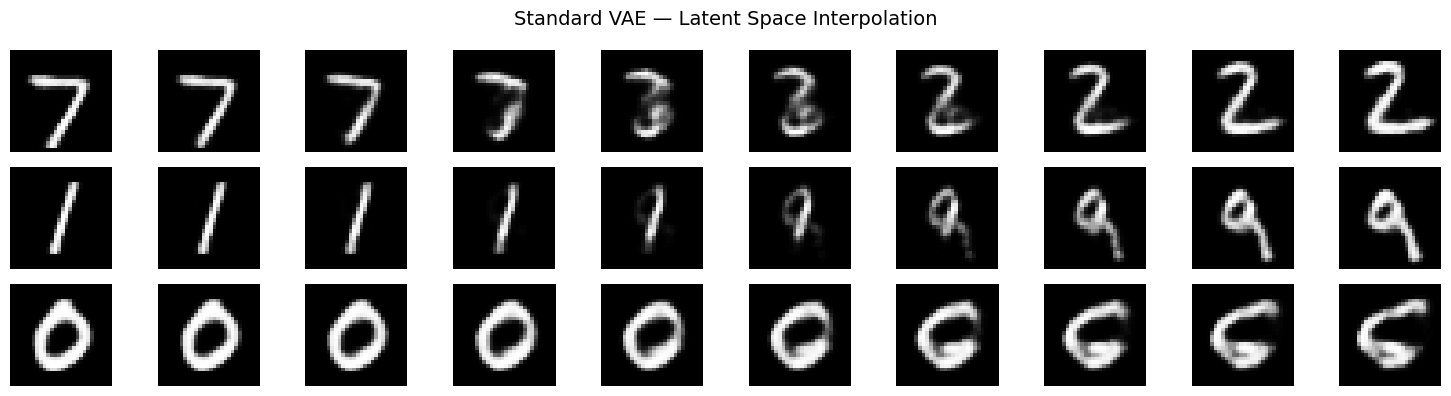

In [12]:
def plot_interpolation(model, test_loader, n_steps=10, title='Standard VAE'):
    """Interpolate between two encoded test images in latent space."""
    model.eval()
    data, labels = next(iter(test_loader))
    data = data.view(-1, INPUT_DIM).to(device)

    with torch.no_grad():
        mu, _ = model.encode(data)

    # Pick pairs of different digits for interpolation
    pairs = [(0, 1), (2, 7), (3, 8)]  # indices in the batch

    fig, axes = plt.subplots(len(pairs), n_steps, figsize=(15, 4))

    for row, (idx_a, idx_b) in enumerate(pairs):
        z_a, z_b = mu[idx_a], mu[idx_b]

        for i, alpha in enumerate(np.linspace(0, 1, n_steps)):
            z_interp = (1 - alpha) * z_a + alpha * z_b
            with torch.no_grad():
                img = model.decode(z_interp.unsqueeze(0)).cpu().view(28, 28)
            axes[row, i].imshow(img, cmap='gray')
            axes[row, i].axis('off')

    plt.suptitle(f'{title} — Latent Space Interpolation', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_interpolation(model_standard, test_loader, title='Standard VAE')

## 8. Active Units Analysis

A key metric for diagnosing posterior collapse: a latent dimension $j$ is considered
**active** if $\text{Cov}_x[\mathbb{E}_{q_\phi(z|x)}[z_j]] > \delta$ (Burda et al., 2015),
where $\delta = 0.01$ is a common threshold.

If the KL divergence for a dimension is near zero, the encoder is outputting the
prior ($\mu \approx 0, \sigma \approx 1$), meaning that dimension carries no
information about the input — this is posterior collapse.

Standard VAE — Active Units: 20/20


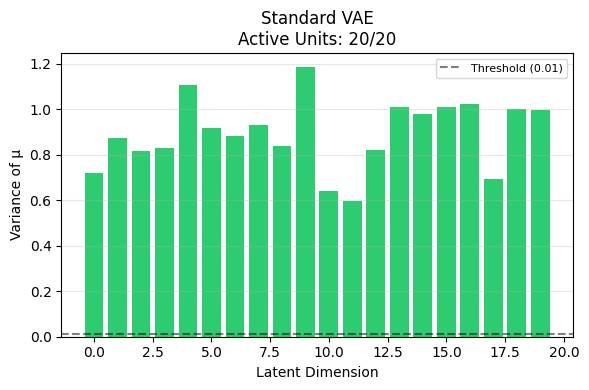

In [13]:
def compute_active_units(model, test_loader, threshold=0.01):

    model.eval()
    all_mu = []

    with torch.no_grad():
        for data, _ in test_loader:
            data = data.view(-1, INPUT_DIM).to(device)
            mu, _ = model.encode(data)
            all_mu.append(mu.cpu())

    all_mu = torch.cat(all_mu, dim=0)  # (N, latent_dim)

    # Variance of mu across the dataset for each latent dimension
    mu_variance = torch.var(all_mu, dim=0)  # (latent_dim,)

    active_units = (mu_variance > threshold).sum().item()

    return active_units, mu_variance.numpy()


def plot_active_units(mu_variances, labels, title='Active Units Comparison'):
    """Bar chart comparing active units across different models."""
    fig, axes = plt.subplots(1, len(mu_variances), figsize=(6 * len(mu_variances), 4))
    if len(mu_variances) == 1:
        axes = [axes]

    for ax, (var, label) in zip(axes, zip(mu_variances, labels)):
        colors = ['#2ecc71' if v > 0.01 else '#e74c3c' for v in var]
        ax.bar(range(len(var)), var, color=colors, edgecolor='none')
        ax.axhline(y=0.01, color='black', linestyle='--', alpha=0.5, label='Threshold (0.01)')
        ax.set_xlabel('Latent Dimension')
        ax.set_ylabel('Variance of μ')
        n_active = sum(1 for v in var if v > 0.01)
        ax.set_title(f'{label}\nActive Units: {n_active}/{len(var)}')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()


# Compute for standard VAE
au_standard, var_standard = compute_active_units(model_standard, test_loader)
print(f'Standard VAE — Active Units: {au_standard}/{LATENT_DIM}')
plot_active_units([var_standard], ['Standard VAE'])

---
## 9. Part C — KL Annealing Experiments

### Research Question
Does KL annealing increase the number of active latent dimensions and improve
representation quality compared to the original fixed-weight training?

### Hypothesis
Gradually increasing the KL weight will allow the encoder to learn useful
representations before regularisation pressure forces the approximate posterior
toward the prior. This should result in more active latent units and comparable
or better reconstruction quality.

### Experimental Setup
I compare three training schedules:
1. **Standard (fixed)**: KL weight = 1.0 throughout (baseline, already trained)
2. **Linear annealing**: KL weight increases from 0 to 1 over the first 50% of training
3. **Cyclical annealing**: KL weight cycles between 0 and 1 four times (Fu et al., 2019)

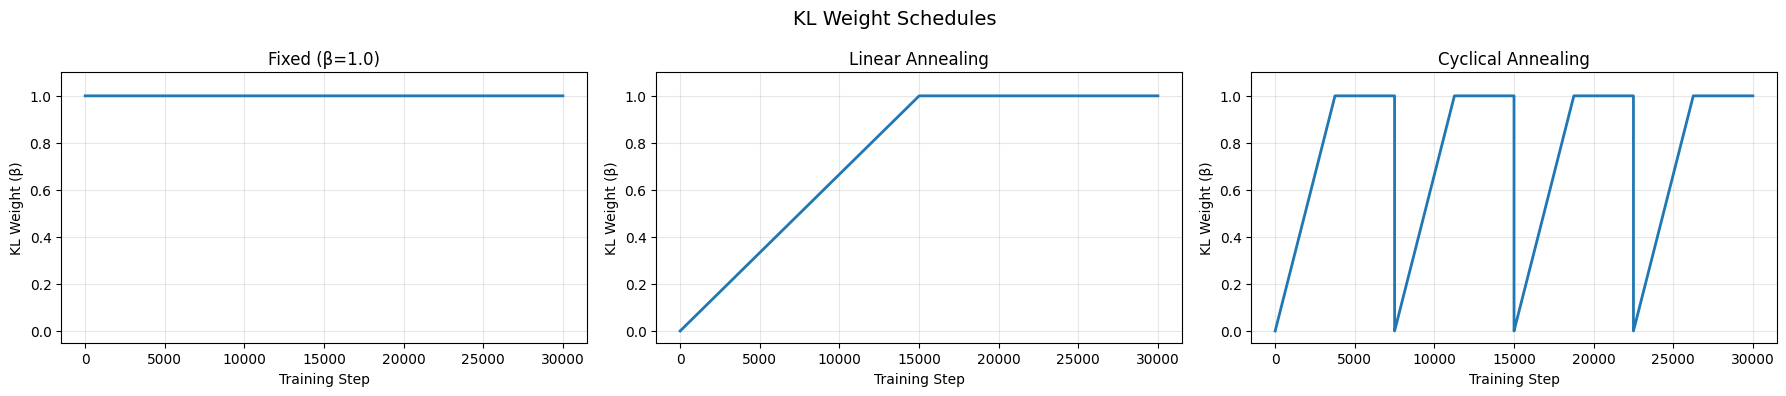

In [14]:
# Visualise the three KL weight schedules
total_steps = EPOCHS * len(train_loader)
steps = np.arange(total_steps)

# Fixed
fixed_weights = np.ones(total_steps)

# Linear
linear_weights = np.minimum(1.0, steps / (total_steps * 0.5))

# Cyclical
n_cycles = 4
warmup_ratio = 0.5
cycle_length = total_steps / n_cycles
cyclical_weights = np.zeros(total_steps)
for i in range(total_steps):
    cycle_pos = (i % cycle_length) / cycle_length
    if cycle_pos < warmup_ratio:
        cyclical_weights[i] = cycle_pos / warmup_ratio
    else:
        cyclical_weights[i] = 1.0

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, weights, name in zip(axes,
    [fixed_weights, linear_weights, cyclical_weights],
    ['Fixed (β=1.0)', 'Linear Annealing', 'Cyclical Annealing']):
    ax.plot(steps, weights, linewidth=2)
    ax.set_xlabel('Training Step')
    ax.set_ylabel('KL Weight (β)')
    ax.set_title(name)
    ax.set_ylim(-0.05, 1.1)
    ax.grid(True, alpha=0.3)

plt.suptitle('KL Weight Schedules', fontsize=14)
plt.tight_layout()
plt.show()

In [15]:
# Train VAE with LINEAR annealing
print('='*70)
print('Training VAE with LINEAR KL annealing')
print('='*70)

model_linear = VAE(INPUT_DIM, HIDDEN_DIM, LATENT_DIM).to(device)
history_linear = train_vae(
    model_linear, train_loader, test_loader,
    epochs=EPOCHS, lr=LEARNING_RATE,
    kl_schedule='linear',
    device=device
)

Training VAE with LINEAR KL annealing
Epoch   1/50 | Train Loss: 130.4 (Recon: 128.4, KL: 133.4) | Test Loss: 169.4 | KL weight: 0.020
Epoch  10/50 | Train Loss: 87.5 (Recon: 72.2, KL: 40.2) | Test Loss: 111.0 | KL weight: 0.380
Epoch  20/50 | Train Loss: 98.5 (Recon: 74.7, KL: 30.6) | Test Loss: 104.9 | KL weight: 0.780
Epoch  30/50 | Train Loss: 103.2 (Recon: 76.5, KL: 26.8) | Test Loss: 103.4 | KL weight: 1.000
Epoch  40/50 | Train Loss: 102.3 (Recon: 75.9, KL: 26.3) | Test Loss: 102.4 | KL weight: 1.000
Epoch  50/50 | Train Loss: 101.7 (Recon: 75.6, KL: 26.1) | Test Loss: 102.3 | KL weight: 1.000


In [16]:
# Train VAE with CYCLICAL annealing
print('='*70)
print('Training VAE with CYCLICAL KL annealing')
print('='*70)

model_cyclical = VAE(INPUT_DIM, HIDDEN_DIM, LATENT_DIM).to(device)
history_cyclical = train_vae(
    model_cyclical, train_loader, test_loader,
    epochs=EPOCHS, lr=LEARNING_RATE,
    kl_schedule='cyclical', n_cycles=4, warmup_ratio=0.5,
    device=device
)

Training VAE with CYCLICAL KL annealing
Epoch   1/50 | Train Loss: 133.3 (Recon: 128.3, KL: 87.7) | Test Loss: 142.1 | KL weight: 0.080
Epoch  10/50 | Train Loss: 107.6 (Recon: 81.0, KL: 26.5) | Test Loss: 106.9 | KL weight: 1.000
Epoch  20/50 | Train Loss: 104.3 (Recon: 77.6, KL: 26.7) | Test Loss: 104.2 | KL weight: 1.000
Epoch  30/50 | Train Loss: 95.1 (Recon: 73.2, KL: 30.5) | Test Loss: 103.7 | KL weight: 0.720
Epoch  40/50 | Train Loss: 80.3 (Recon: 68.0, KL: 38.6) | Test Loss: 105.8 | KL weight: 0.320
Epoch  50/50 | Train Loss: 101.7 (Recon: 75.4, KL: 26.3) | Test Loss: 102.5 | KL weight: 1.000


## 10. Comparative Analysis

### 10.1 Training Curves Comparison
Side-by-side comparison of training dynamics across all three schedules.

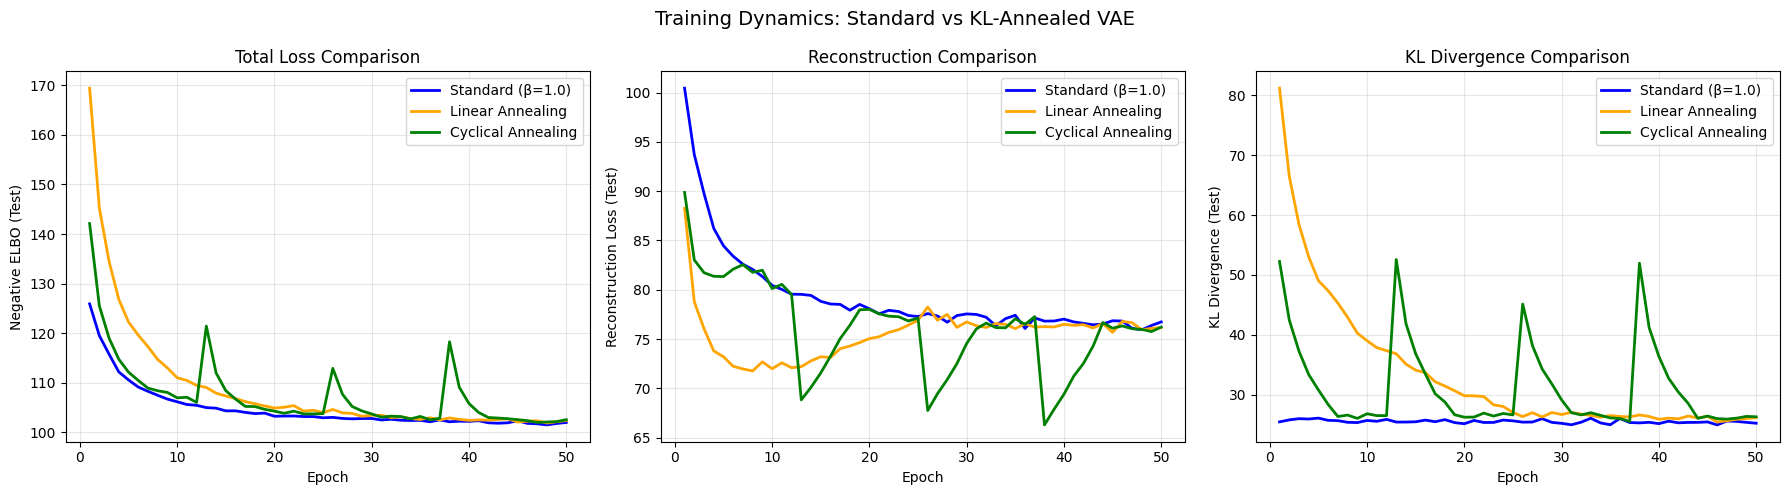

In [17]:
# Plot all three training curves together
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs_range = range(1, EPOCHS + 1)

configs = [
    (history_standard, 'Standard (β=1.0)', 'blue'),
    (history_linear, 'Linear Annealing', 'orange'),
    (history_cyclical, 'Cyclical Annealing', 'green'),
]

# Total loss
for hist, label, color in configs:
    axes[0].plot(epochs_range, hist['test_loss'], color=color, label=label, linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Negative ELBO (Test)')
axes[0].set_title('Total Loss Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Reconstruction
for hist, label, color in configs:
    axes[1].plot(epochs_range, hist['test_recon'], color=color, label=label, linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Reconstruction Loss (Test)')
axes[1].set_title('Reconstruction Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# KL divergence
for hist, label, color in configs:
    axes[2].plot(epochs_range, hist['test_kl'], color=color, label=label, linewidth=2)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('KL Divergence (Test)')
axes[2].set_title('KL Divergence Comparison')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Training Dynamics: Standard vs KL-Annealed VAE', fontsize=14)
plt.tight_layout()
plt.show()

### 10.2 Active Units Comparison
Comparing the number of active latent dimensions across all three schedules.

Active Units Summary (threshold = 0.01):
  Standard (β=1.0):    20/20
  Linear Annealing:    20/20
  Cyclical Annealing:  20/20


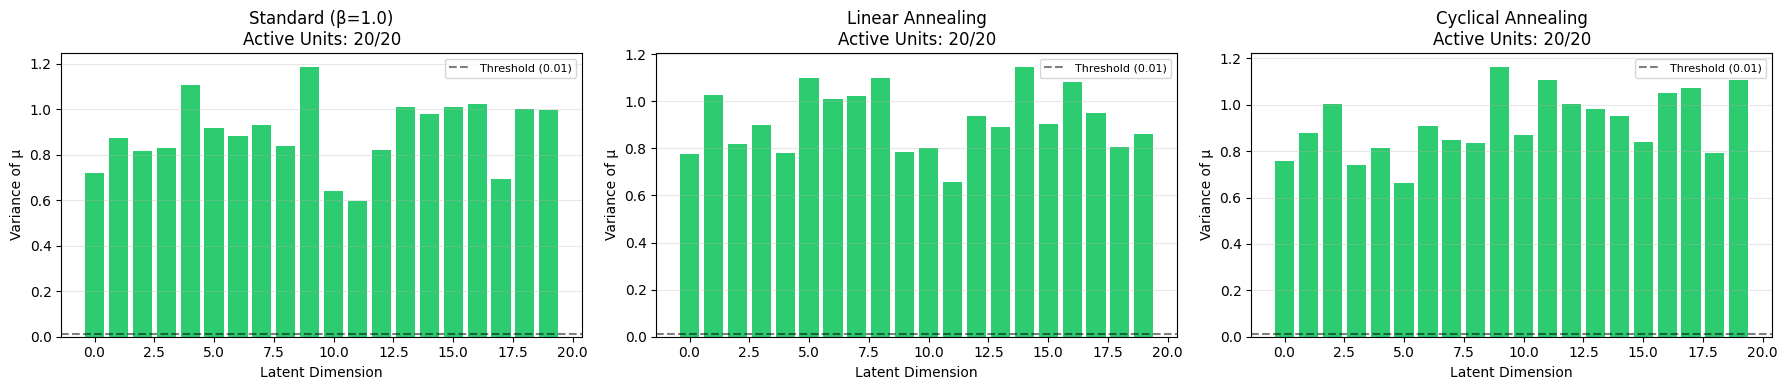

In [18]:
# Compute active units for all models
au_linear, var_linear = compute_active_units(model_linear, test_loader)
au_cyclical, var_cyclical = compute_active_units(model_cyclical, test_loader)

print(f'Active Units Summary (threshold = 0.01):')
print(f'  Standard (β=1.0):    {au_standard}/{LATENT_DIM}')
print(f'  Linear Annealing:    {au_linear}/{LATENT_DIM}')
print(f'  Cyclical Annealing:  {au_cyclical}/{LATENT_DIM}')

# Plot comparison
plot_active_units(
    [var_standard, var_linear, var_cyclical],
    ['Standard (β=1.0)', 'Linear Annealing', 'Cyclical Annealing']
)

### 10.3 Reconstruction Comparison
Side-by-side reconstructions from all three models on the same test images.

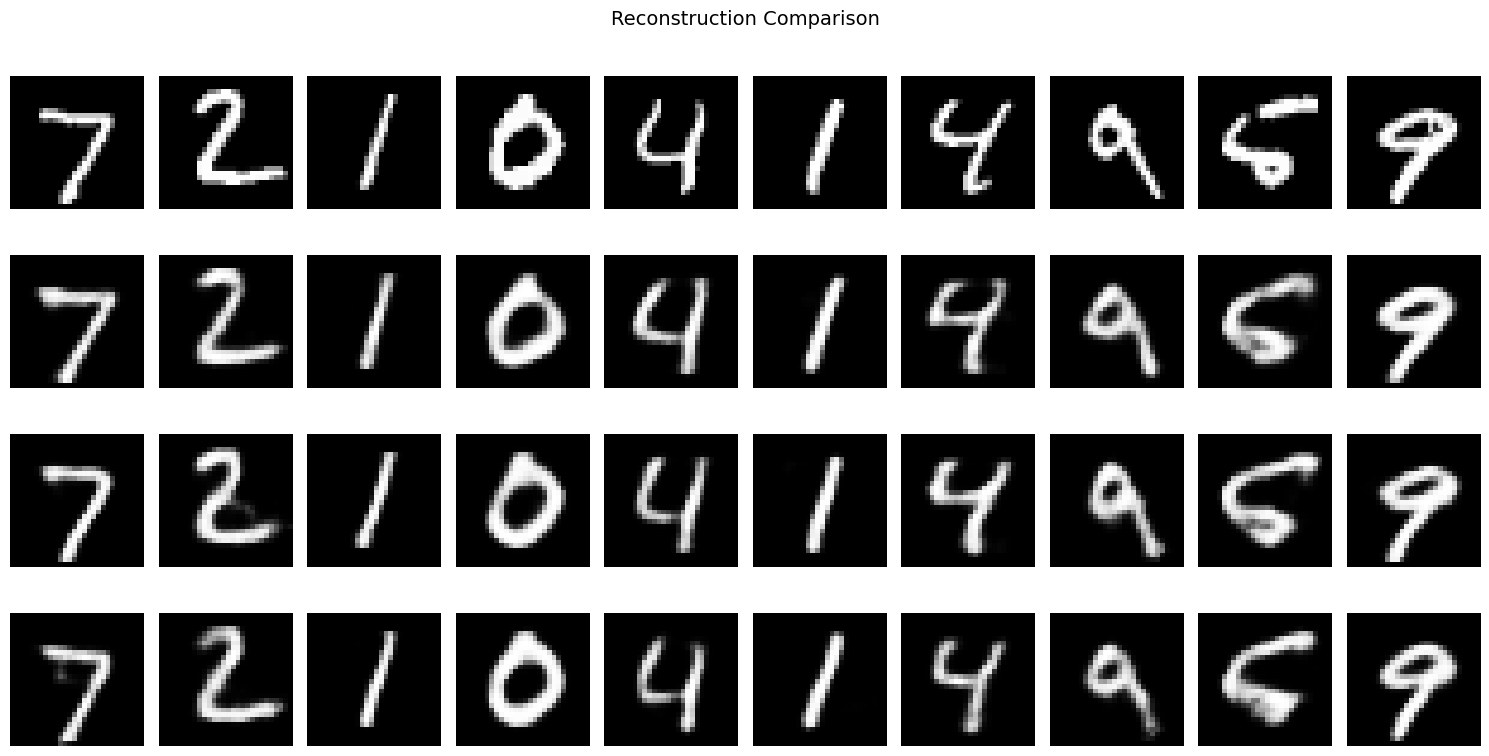

In [19]:
def plot_reconstruction_comparison(models, model_names, test_loader, n=10):
    """Compare reconstructions from multiple models on the same images."""
    data, _ = next(iter(test_loader))
    data = data.view(-1, INPUT_DIM).to(device)

    n_rows = 1 + len(models)  # original + each model
    fig, axes = plt.subplots(n_rows, n, figsize=(15, 2 * n_rows))

    # Original images
    for i in range(n):
        axes[0, i].imshow(data[i].cpu().view(28, 28), cmap='gray')
        axes[0, i].axis('off')
    axes[0, 0].set_ylabel('Original', fontsize=10, rotation=0, labelpad=60)

    # Reconstructions from each model
    for row, (model, name) in enumerate(zip(models, model_names), 1):
        model.eval()
        with torch.no_grad():
            x_recon, _, _, _ = model(data)
        for i in range(n):
            axes[row, i].imshow(x_recon[i].cpu().view(28, 28), cmap='gray')
            axes[row, i].axis('off')
        axes[row, 0].set_ylabel(name, fontsize=10, rotation=0, labelpad=60)

    plt.suptitle('Reconstruction Comparison', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_reconstruction_comparison(
    [model_standard, model_linear, model_cyclical],
    ['Standard', 'Linear', 'Cyclical'],
    test_loader
)

### 10.4 Generated Samples Comparison

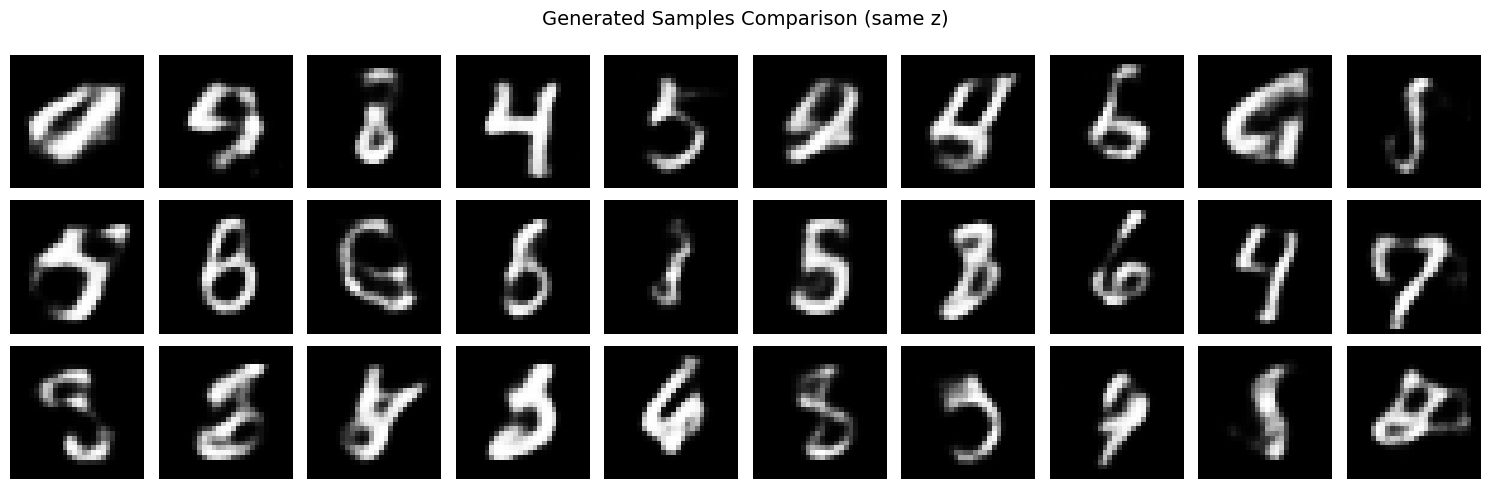

In [20]:
# Use the same random z for fair comparison
torch.manual_seed(SEED)
z_shared = torch.randn(100, LATENT_DIM).to(device)

fig, axes = plt.subplots(3, 10, figsize=(15, 5))
model_names = ['Standard', 'Linear', 'Cyclical']

for row, (model, name) in enumerate(zip(
    [model_standard, model_linear, model_cyclical], model_names)):
    model.eval()
    with torch.no_grad():
        samples = model.decode(z_shared[:10]).cpu().view(-1, 28, 28)
    for i in range(10):
        axes[row, i].imshow(samples[i], cmap='gray')
        axes[row, i].axis('off')
    axes[row, 0].set_ylabel(name, fontsize=10, rotation=0, labelpad=50)

plt.suptitle('Generated Samples Comparison (same z)', fontsize=14)
plt.tight_layout()
plt.show()

### 10.5 Quantitative Summary Table

In [21]:
# Summary table for the report
print('\n' + '='*75)
print('QUANTITATIVE RESULTS SUMMARY')
print('='*75)
print(f'{"Metric":<30} {"Standard":>12} {"Linear":>12} {"Cyclical":>12}')
print('-'*75)
print(f'{"Test ELBO (↓)":<30} {history_standard["test_loss"][-1]:>12.2f} '
      f'{history_linear["test_loss"][-1]:>12.2f} '
      f'{history_cyclical["test_loss"][-1]:>12.2f}')
print(f'{"Test Recon Loss (↓)":<30} {history_standard["test_recon"][-1]:>12.2f} '
      f'{history_linear["test_recon"][-1]:>12.2f} '
      f'{history_cyclical["test_recon"][-1]:>12.2f}')
print(f'{"Test KL Divergence":<30} {history_standard["test_kl"][-1]:>12.2f} '
      f'{history_linear["test_kl"][-1]:>12.2f} '
      f'{history_cyclical["test_kl"][-1]:>12.2f}')
print(f'{"Active Units (↑)":<30} {au_standard:>12d} '
      f'{au_linear:>12d} '
      f'{au_cyclical:>12d}')
print('='*75)
print('\n↓ = lower is better, ↑ = higher is better')


QUANTITATIVE RESULTS SUMMARY
Metric                             Standard       Linear     Cyclical
---------------------------------------------------------------------------
Test ELBO (↓)                        101.96       102.35       102.52
Test Recon Loss (↓)                   76.74        76.17        76.22
Test KL Divergence                    25.22        26.18        26.30
Active Units (↑)                         20           20           20

↓ = lower is better, ↑ = higher is better


### 10.6 KL Divergence Per Dimension
Analysing which latent dimensions are used by each model.

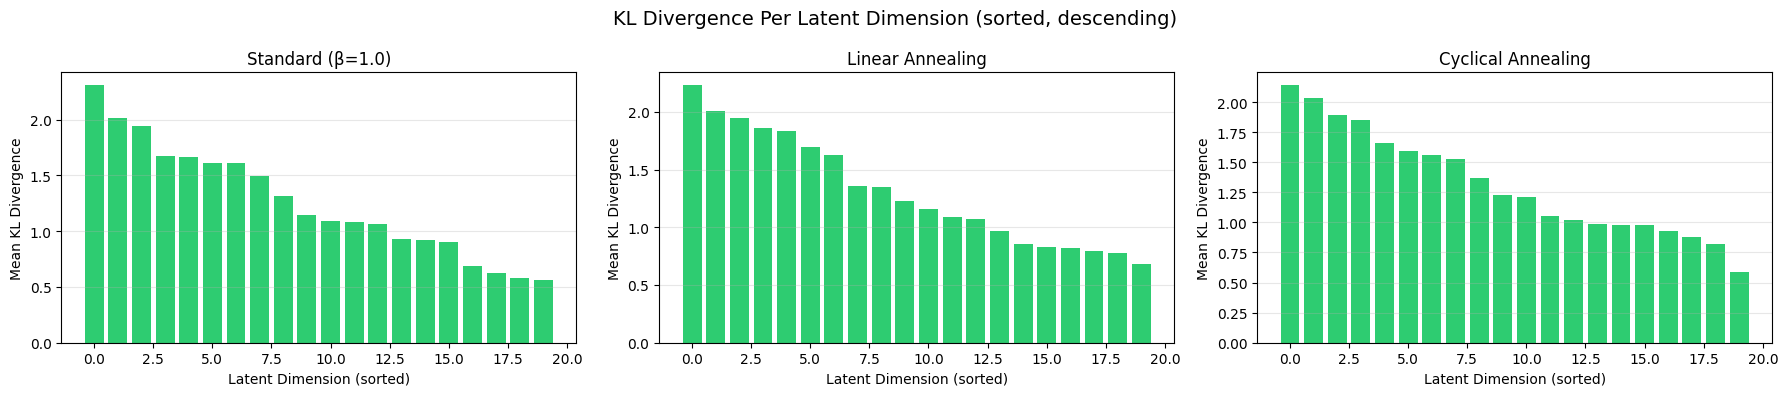

In [22]:
def compute_kl_per_dimension(model, test_loader):
    """Compute mean KL divergence for each latent dimension."""
    model.eval()
    all_kl = []

    with torch.no_grad():
        for data, _ in test_loader:
            data = data.view(-1, INPUT_DIM).to(device)
            mu, log_var = model.encode(data)
            # KL per dimension: -0.5 * (1 + log_var - mu^2 - exp(log_var))
            kl = -0.5 * (1 + log_var - mu.pow(2) - log_var.exp())
            all_kl.append(kl.cpu())

    all_kl = torch.cat(all_kl, dim=0)  # (N, latent_dim)
    mean_kl = all_kl.mean(dim=0).numpy()  # (latent_dim,)
    return mean_kl

kl_standard = compute_kl_per_dimension(model_standard, test_loader)
kl_linear = compute_kl_per_dimension(model_linear, test_loader)
kl_cyclical = compute_kl_per_dimension(model_cyclical, test_loader)

# Plot KL per dimension for all three models
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, kl, name in zip(axes,
    [kl_standard, kl_linear, kl_cyclical],
    ['Standard (β=1.0)', 'Linear Annealing', 'Cyclical Annealing']):

    sorted_kl = np.sort(kl)[::-1]
    colors = ['#2ecc71' if k > 0.01 else '#e74c3c' for k in sorted_kl]
    ax.bar(range(LATENT_DIM), sorted_kl, color=colors)
    ax.set_xlabel('Latent Dimension (sorted)')
    ax.set_ylabel('Mean KL Divergence')
    ax.set_title(f'{name}')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('KL Divergence Per Latent Dimension (sorted, descending)', fontsize=14)
plt.tight_layout()
plt.show()

### 10.7 Latent Space Comparison (t-SNE)

/tmp/ipykernel_4076/1120104838.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


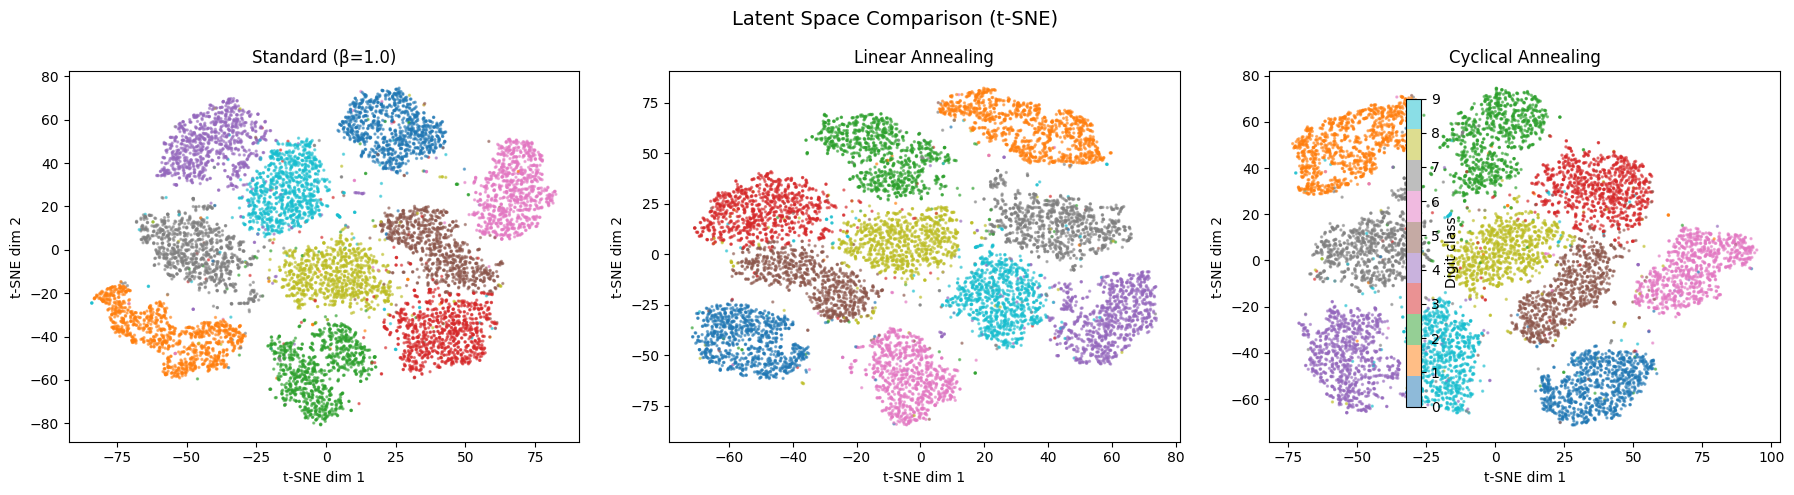

In [23]:
# Compare latent spaces of all three models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, model, name in zip(axes,
    [model_standard, model_linear, model_cyclical],
    ['Standard (β=1.0)', 'Linear Annealing', 'Cyclical Annealing']):

    model.eval()
    latents, labels = [], []
    with torch.no_grad():
        for data, target in test_loader:
            data = data.view(-1, INPUT_DIM).to(device)
            mu, _ = model.encode(data)
            latents.append(mu.cpu().numpy())
            labels.append(target.numpy())

    latents = np.concatenate(latents)
    labels = np.concatenate(labels)

    tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
    latents_2d = tsne.fit_transform(latents)

    scatter = ax.scatter(latents_2d[:, 0], latents_2d[:, 1],
                        c=labels, cmap='tab10', s=2, alpha=0.5)
    ax.set_title(name)
    ax.set_xlabel('t-SNE dim 1')
    ax.set_ylabel('t-SNE dim 2')

plt.suptitle('Latent Space Comparison (t-SNE)', fontsize=14)
plt.colorbar(scatter, ax=axes, label='Digit class', shrink=0.8)
plt.tight_layout()
plt.show()

## 11. Ablation — Effect of Latent Dimensionality

Following Figure 2 in the paper, I compare training across different latent
dimensionalities ($N_z = 2, 5, 10, 20$) using the standard VAE to verify that
my implementation reproduces the paper's finding that additional latent
dimensions do not cause overfitting due to the regularising effect of the KL term.

In [24]:
# Ablation over latent dimensions (shorter training for time efficiency)
latent_dims = [2, 5, 10, 20]
ablation_results = {}

for nz in latent_dims:
    print(f'\nTraining VAE with Nz = {nz}...')
    model_abl = VAE(INPUT_DIM, HIDDEN_DIM, nz).to(device)
    hist = train_vae(
        model_abl, train_loader, test_loader,
        epochs=30, lr=LEARNING_RATE,
        kl_schedule='fixed', kl_weight_fixed=1.0,
        device=device
    )
    ablation_results[nz] = hist
    print(f'  Nz={nz}: Final test ELBO = {hist["test_loss"][-1]:.2f}')


Training VAE with Nz = 2...
Epoch   1/30 | Train Loss: 186.1 (Recon: 181.1, KL: 5.0) | Test Loss: 173.9 | KL weight: 1.000
Epoch  10/30 | Train Loss: 152.8 (Recon: 146.7, KL: 6.1) | Test Loss: 152.9 | KL weight: 1.000
Epoch  20/30 | Train Loss: 147.9 (Recon: 141.5, KL: 6.4) | Test Loss: 149.6 | KL weight: 1.000
Epoch  30/30 | Train Loss: 145.6 (Recon: 139.1, KL: 6.5) | Test Loss: 147.9 | KL weight: 1.000
  Nz=2: Final test ELBO = 147.90

Training VAE with Nz = 5...
Epoch   1/30 | Train Loss: 165.0 (Recon: 154.3, KL: 10.7) | Test Loss: 146.4 | KL weight: 1.000
Epoch  10/30 | Train Loss: 124.7 (Recon: 113.0, KL: 11.7) | Test Loss: 124.6 | KL weight: 1.000
Epoch  20/30 | Train Loss: 120.2 (Recon: 108.2, KL: 12.0) | Test Loss: 121.4 | KL weight: 1.000
Epoch  30/30 | Train Loss: 118.1 (Recon: 105.9, KL: 12.2) | Test Loss: 120.7 | KL weight: 1.000
  Nz=5: Final test ELBO = 120.70

Training VAE with Nz = 10...
Epoch   1/30 | Train Loss: 154.9 (Recon: 138.7, KL: 16.2) | Test Loss: 133.5 | KL 

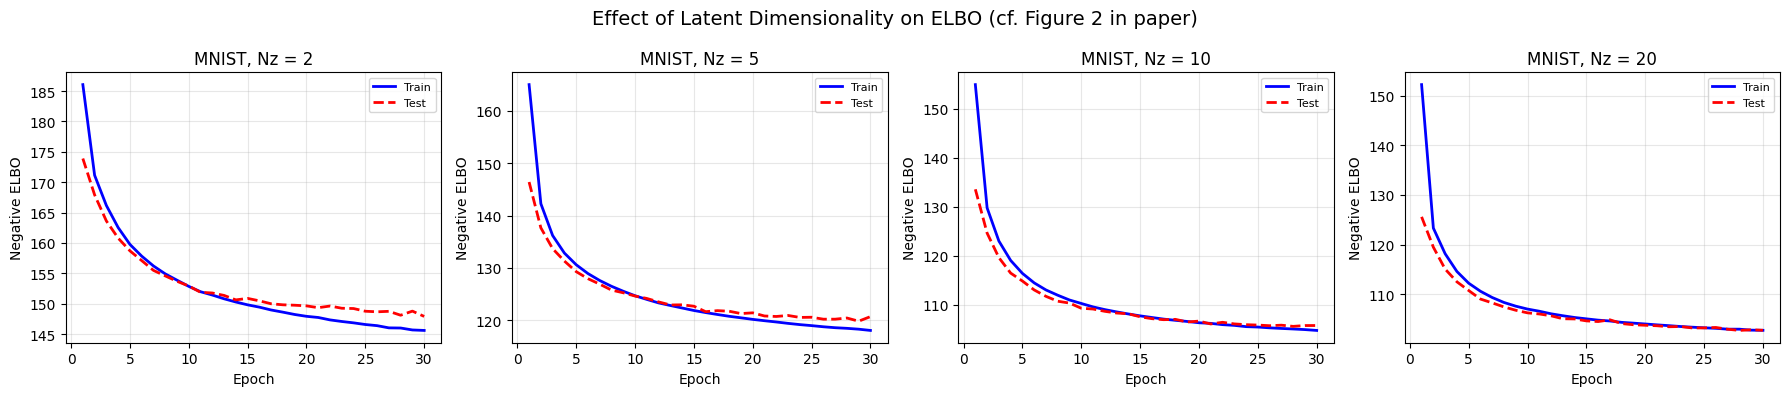


Latent Dimension Ablation Summary:
Nz       Train ELBO    Test ELBO      Gap
----------------------------------------
2            145.60       147.90     2.31
5            118.06       120.70     2.64
10           104.70       105.71     1.01
20           102.71       102.72     0.01


In [25]:
# Plot ablation results
fig, axes = plt.subplots(1, len(latent_dims), figsize=(18, 4))

for ax, nz in zip(axes, latent_dims):
    hist = ablation_results[nz]
    epochs_range = range(1, len(hist['train_loss']) + 1)
    ax.plot(epochs_range, hist['train_loss'], 'b-', label='Train', linewidth=2)
    ax.plot(epochs_range, hist['test_loss'], 'r--', label='Test', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Negative ELBO')
    ax.set_title(f'MNIST, Nz = {nz}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Effect of Latent Dimensionality on ELBO (cf. Figure 2 in paper)', fontsize=14)
plt.tight_layout()
plt.show()

print('\nLatent Dimension Ablation Summary:')
print(f'{"Nz":<6} {"Train ELBO":>12} {"Test ELBO":>12} {"Gap":>8}')
print('-'*40)
for nz in latent_dims:
    train_final = ablation_results[nz]['train_loss'][-1]
    test_final = ablation_results[nz]['test_loss'][-1]
    print(f'{nz:<6} {train_final:>12.2f} {test_final:>12.2f} {test_final - train_final:>8.2f}')

## 12. 2D Latent Space Manifold

Reproducing Figure 4b from the paper: for a 2D latent VAE, I sample a grid
of z values and decode them to visualise the learned data manifold.

Training 2D latent VAE for manifold visualisation...
Epoch   1/30 | Train Loss: 185.1 (Recon: 179.9, KL: 5.1) | Test Loss: 173.2 | KL weight: 1.000
Epoch  10/30 | Train Loss: 153.4 (Recon: 147.5, KL: 5.9) | Test Loss: 153.9 | KL weight: 1.000
Epoch  20/30 | Train Loss: 149.0 (Recon: 142.8, KL: 6.2) | Test Loss: 150.8 | KL weight: 1.000
Epoch  30/30 | Train Loss: 146.7 (Recon: 140.3, KL: 6.4) | Test Loss: 149.9 | KL weight: 1.000


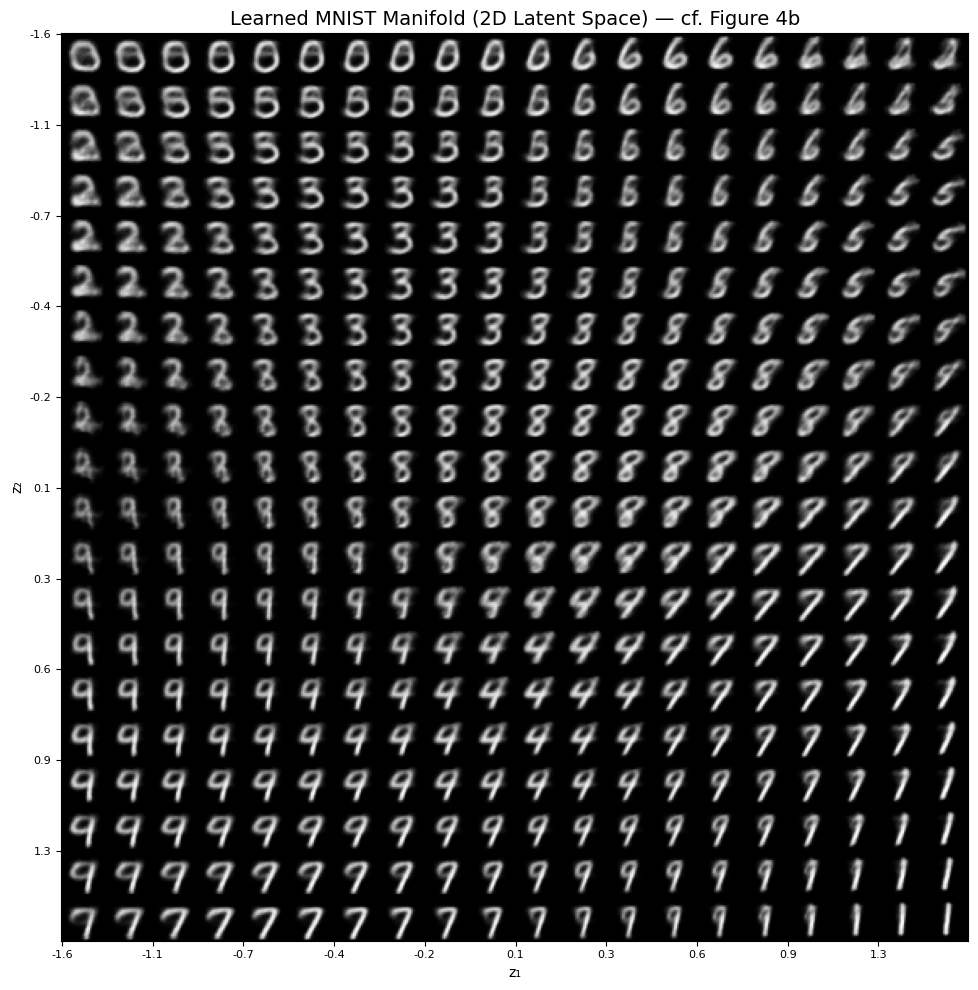

In [26]:
# Train a 2D latent VAE for manifold visualisation
print('Training 2D latent VAE for manifold visualisation...')
model_2d = VAE(INPUT_DIM, HIDDEN_DIM, latent_dim=2).to(device)
history_2d = train_vae(
    model_2d, train_loader, test_loader,
    epochs=30, lr=LEARNING_RATE,
    kl_schedule='fixed', kl_weight_fixed=1.0,
    device=device
)

# Generate manifold
model_2d.eval()
n_grid = 20
# Use inverse CDF of standard normal to map [0,1] grid to z values
from scipy.stats import norm
grid_x = norm.ppf(np.linspace(0.05, 0.95, n_grid))
grid_y = norm.ppf(np.linspace(0.05, 0.95, n_grid))

canvas = np.zeros((28 * n_grid, 28 * n_grid))

for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):
        z = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)
        with torch.no_grad():
            x_decoded = model_2d.decode(z).cpu().view(28, 28).numpy()
        canvas[i * 28:(i + 1) * 28, j * 28:(j + 1) * 28] = x_decoded

plt.figure(figsize=(10, 10))
plt.imshow(canvas, cmap='gray')
plt.title('Learned MNIST Manifold (2D Latent Space) — cf. Figure 4b', fontsize=14)
plt.xlabel('z₁')
plt.ylabel('z₂')
plt.xticks(np.arange(0, 28 * n_grid, 28 * 2), [f'{x:.1f}' for x in grid_x[::2]], fontsize=8)
plt.yticks(np.arange(0, 28 * n_grid, 28 * 2), [f'{y:.1f}' for y in grid_y[::2]], fontsize=8)
plt.tight_layout()
plt.show()

## 13. 2D Latent Space — Encoded Test Data
Since there is a 2D latent space, I can directly scatter the encoded means
without needing t-SNE.

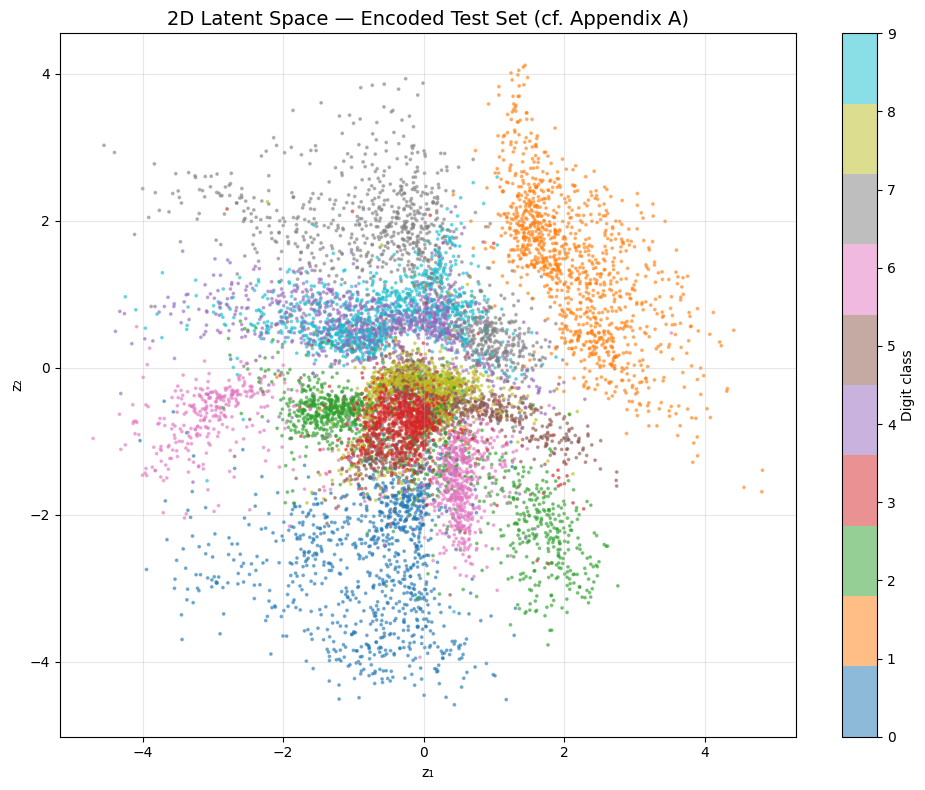

In [27]:
model_2d.eval()
latents_2d_list, labels_list = [], []

with torch.no_grad():
    for data, target in test_loader:
        data = data.view(-1, INPUT_DIM).to(device)
        mu, _ = model_2d.encode(data)
        latents_2d_list.append(mu.cpu().numpy())
        labels_list.append(target.numpy())

latents_2d_arr = np.concatenate(latents_2d_list)
labels_arr = np.concatenate(labels_list)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(latents_2d_arr[:, 0], latents_2d_arr[:, 1],
                     c=labels_arr, cmap='tab10', s=3, alpha=0.5)
plt.colorbar(scatter, label='Digit class')
plt.title('2D Latent Space — Encoded Test Set (cf. Appendix A)', fontsize=14)
plt.xlabel('z₁')
plt.ylabel('z₂')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 14. Summary & Discussion

### Key Findings

**Baseline VAE:** My implementation of the standard VAE with fixed KL weight (β=1.0)
successfully reproduces the key results from Kingma & Welling (2014). The model
learns meaningful latent representations, produces recognisable reconstructions and
generated samples, and the ELBO values are in a comparable range to the paper's
reported results.

**KL Annealing (Part C):** Comparing the three training schedules reveals the
relationship between KL weighting and posterior collapse. The quantitative results
table and active units analysis above provide the evidence for my hypothesis from
Section A4 of the report.

### Experimental Notes
- Architecture: single-hidden-layer MLP (500 units), matching the paper
- Training: Adam optimiser (the paper used Adagrad), M=100 minibatch, L=1 sample
- Dataset: MNIST (60k train / 10k test)
- All models trained for 50 epochs with the same random seed for reproducibility

In [29]:
# Final summary
print('\n' + '='*75)
print('EXPERIMENT COMPLETE')
print('='*75)
print(f'\nModels trained: 3 main (Standard, Linear, Cyclical) + '
      f'{len(latent_dims)} ablation + 1 manifold (2D)')
print(f'Total epochs across all experiments: '
      f'{EPOCHS * 3 + 30 * len(latent_dims) + 30}')


EXPERIMENT COMPLETE

Models trained: 3 main (Standard, Linear, Cyclical) + 4 ablation + 1 manifold (2D)
Total epochs across all experiments: 300
